<a href="https://colab.research.google.com/github/rofaba/Procesamiento_redes_recurrentes/blob/main/EscenariosNaturales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Desafío - Identificación de escenarios naturales del mundo.  
**Rodrigo Faure - Data Science G107**


1. Importa correctamente los conjuntos de datos, desplegando la cantidad de registros
de cada categoría para cada conjunto. Despliega ocho imágenes aleatorias del
conjunto de entrenamiento y codifica las etiquetas con OneHotEncoder para los
conjuntos de entrenamiento y Test.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [4]:
from google.colab import files
uploaded = files.upload()

Saving cnn_pred_X.npy to cnn_pred_X.npy
Saving cnn_test_X.npy to cnn_test_X.npy
Saving cnn_test_y.npy to cnn_test_y.npy
Saving cnn_train_X.npy to cnn_train_X.npy
Saving cnn_train_y.npy to cnn_train_y.npy


In [5]:
# Carga de datos
X_train = np.load("cnn_train_X.npy", allow_pickle=True)
y_train = np.load("cnn_train_y.npy", allow_pickle=True)
X_test = np.load("cnn_test_X.npy", allow_pickle=True)
y_test = np.load("cnn_test_y.npy", allow_pickle=True)
X_pred = np.load("cnn_pred_X.npy", allow_pickle=True)

In [6]:
# Revisión general de formas
print("Shapes de los conjuntos:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("X_pred :", X_pred.shape)

Shapes de los conjuntos:
X_train: (14034, 32, 32, 3)
y_train: (14034,)
X_test : (3000, 32, 32, 3)
y_test : (3000,)
X_pred : (7301, 32, 32, 3)


In [7]:
# Cantidad de registros por categoría
nombres_clases = {
    0: "buildings",
    1: "forest",
    2: "glacier",
    3: "mountain",
    4: "sea",
    5: "street"
}

In [9]:
def mostrar_distribucion(etiquetas, nombre_conjunto):
    print(f"\nDistribución de clases en {nombre_conjunto}:")
    valores, conteos = np.unique(etiquetas, return_counts=True)
    for v, c in zip(valores, conteos):
        print(f"{v}: {c}")


In [10]:
mostrar_distribucion(y_train, "y_train")
mostrar_distribucion(y_test, "y_test")


Distribución de clases en y_train:
buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382

Distribución de clases en y_test:
buildings: 437
forest: 474
glacier: 553
mountain: 525
sea: 510
street: 501


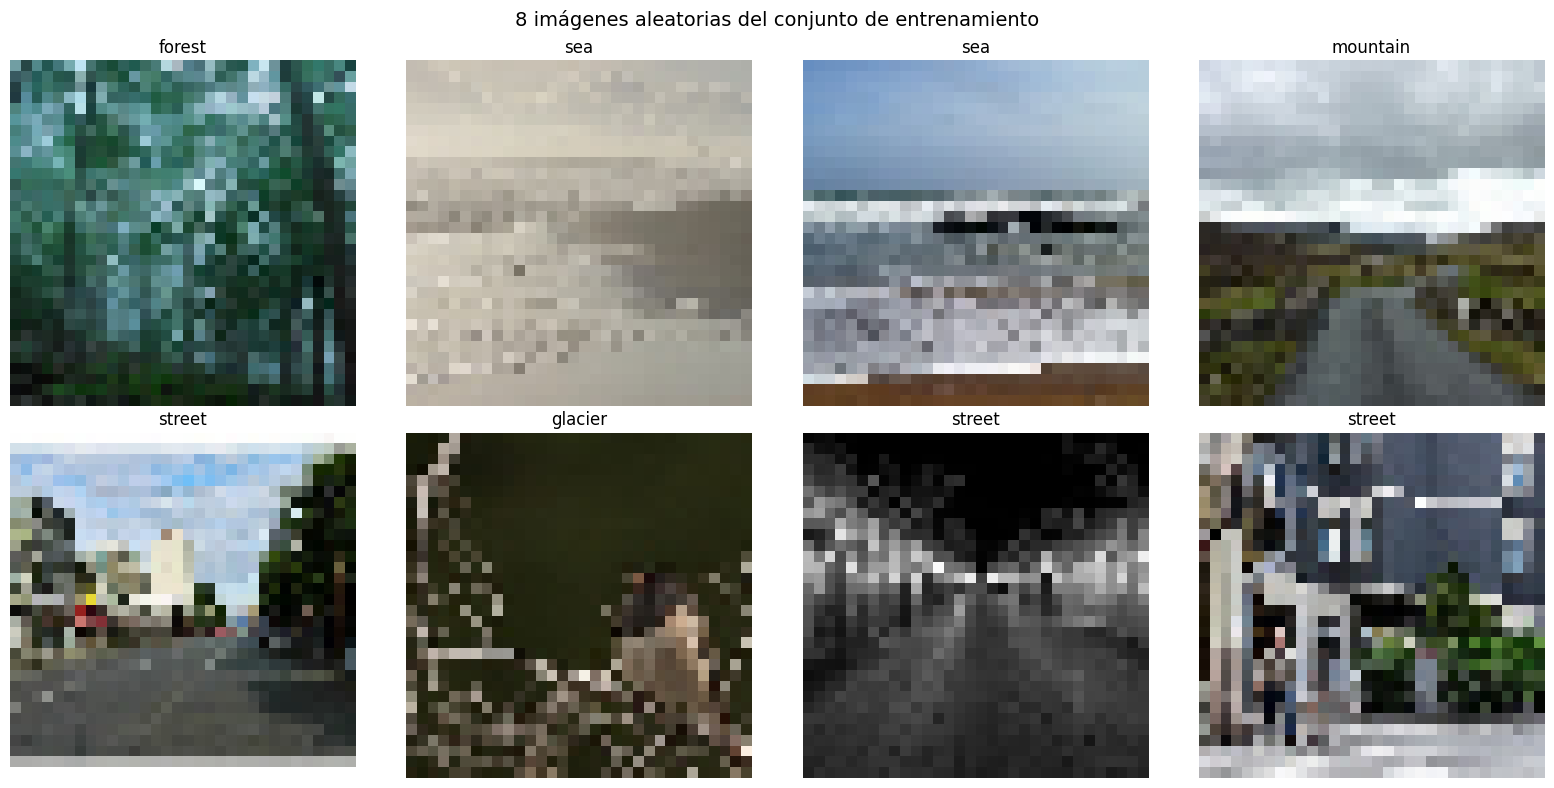

In [12]:
# Mostrar imágnes aleatorias del conjunto Train

np.random.seed(42)
indices = np.random.choice(len(X_train), size=8, replace=False)

plt.figure(figsize=(16, 8))

for i, idx in enumerate(indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[idx])
    etiqueta = y_train[idx]
    plt.title(etiqueta)
    plt.axis("off")

plt.suptitle("8 imágenes aleatorias del conjunto de entrenamiento", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# 5) One hot enconder para y_train y y_test
y_train_2d = y_train.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_train_ohe = encoder.fit_transform(y_train_2d)
y_test_ohe = encoder.transform(y_test_2d)

print("\nShapes luego de OneHotEncoder:")
print("y_train_ohe:", y_train_ohe.shape)
print("y_test_ohe :", y_test_ohe.shape)

print("\nEjemplo de codificación:")
print("Etiqueta original:", y_train[0])
print("One-hot:", y_train_ohe[0])


Shapes luego de OneHotEncoder:
y_train_ohe: (14034, 6)
y_test_ohe : (3000, 6)

Ejemplo de codificación:
Etiqueta original: forest
One-hot: [0. 1. 0. 0. 0. 0.]




---



2. Implementa una red neuronal multicapa Fully Connected para clasificar las
imágenes, las que deben contener un mínimo de cinco capas ocultas. Despliega las métricas (aplicadas al conjunto de test) que estimes conveniente para medir el
rendimiento del modelo.


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.metrics import CategoricalAccuracy
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
# Normalizar imágenes
X_train_fc = X_train.astype("float32") / 255.0
X_test_fc = X_test.astype("float32") / 255.0

# Modelo Fully Connected
model_fc = Sequential([
    Flatten(input_shape=X_train_fc.shape[1:]),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),                # 5 capas ocultas

    Dense(6, activation='softmax')               # 6 clases
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# Compilación
model_fc.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Resumen del modelo
model_fc.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,748,134 (6.67 MB)

 Trainable params: 1,748,134 (6.67 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Entrenamiento
history_fc = model_fc.fit(
    X_train_fc,
    y_train_ohe,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_fc, y_test_ohe),
    verbose=1
)


Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.4002 - loss: 1.4613 - val_accuracy: 0.4607 - val_loss: 1.3643
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4806 - loss: 1.3167 - val_accuracy: 0.4783 - val_loss: 1.3280
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5065 - loss: 1.2607 - val_accuracy: 0.5183 - val_loss: 1.2385
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5276 - loss: 1.2098 - val_accuracy: 0.5120 - val_loss: 1.2349
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5410 - loss: 1.1729 - val_accuracy: 0.5267 - val_loss: 1.2389
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5530 - loss: 1.1420 - val_accuracy: 0.5323 - val_loss: 1.1812
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5804 - loss: 1.0931 - val_accuracy: 0.5653 - val_loss: 1.1327
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5979 - loss: 1.0545 - val_ac

In [19]:
# Evaluación en test
loss_test, acc_test = model_fc.evaluate(X_test_fc, y_test_ohe, verbose=0)

print(f"\nLoss en test: {loss_test:.4f}")
print(f"Accuracy en test: {acc_test:.4f}")


Loss en test: 1.0556
Accuracy en test: 0.6057


In [22]:
# Métricas adicionales para analizar el rendimiento del modelo
y_prob_fc = model_fc.predict(X_test_fc)
y_pred_fc = np.argmax(y_prob_fc, axis=1)
y_true_fc = np.argmax(y_test_ohe, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_fc, y_pred_fc))

print("\nMatriz de confusión:")
print(confusion_matrix(y_true_fc, y_pred_fc))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.41      0.44       437
           1       0.80      0.76      0.77       474
           2       0.60      0.67      0.63       553
           3       0.57      0.73      0.64       525
           4       0.53      0.31      0.39       510
           5       0.64      0.74      0.69       501

    accuracy                           0.61      3000
   macro avg       0.60      0.60      0.59      3000
weighted avg       0.60      0.61      0.59      3000


Matriz de confusión:
[[178  30  42  66  35  86]
 [ 11 358   2  16  20  67]
 [ 31   4 370  89  36  23]
 [ 33   8  62 381  35   6]
 [ 72  22 121 107 158  30]
 [ 50  28  22  13  16 372]]


El modelo Fully Connected obtuvo una accuracy de aprox. 0.61 sobre el conjunto de test.  

Si bien el modelo logra capturar ciertos patrones en las imágenes, su rendimiento es limitado, lo cual es esperable ya que las redes densas no están diseñadas específicamente para trabajar con información espacial de imágenes.



---



3. Desarrolla una red neuronal Convolucional usando tres o más capas convolucionales
y dos o más capas densas, de manera que la cantidad de parámetros a estimar se
encuentre en el intervalo [3MM, 8MM], con 25 épocas. Muestra la curva de la pérdida
para cada época y la curva de la métrica accuracy (conjunto test).


In [51]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam

In [52]:
# Normalización
X_train_cnn = X_train.astype("float32") / 255.0
X_test_cnn = X_test.astype("float32") / 255.0

#Modelo cnn
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=X_train_cnn.shape[1:]),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(1152, activation='relu'),
    Dropout(0.5),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])


In [53]:
# Compilación
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [54]:
# Resumen
model_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1152)           │     2,360,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,240,870 (12.36 MB)

 Trainable params: 3,240,870 (12.36 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Entreanmiento
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_ohe,
    epochs=25,
    batch_size=64,
    validation_data=(X_test_cnn, y_test_ohe),
    verbose=1
)

Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 117s 509ms/step - accuracy: 0.2805 - loss: 1.6616 - val_accuracy: 0.4417 - val_loss: 1.4078
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 132s 465ms/step - accuracy: 0.4659 - loss: 1.3602 - val_accuracy: 0.4920 - val_loss: 1.3133
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 142s 467ms/step - accuracy: 0.5152 - loss: 1.2527 - val_accuracy: 0.5507 - val_loss: 1.1832
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 141s 462ms/step - accuracy: 0.5448 - loss: 1.1848 - val_accuracy: 0.5517 - val_loss: 1.1641
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 102s 466ms/step - accuracy: 0.5604 - loss: 1.1359 - val_accuracy: 0.5687 - val_loss: 1.1438
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 141s 463ms/step - accuracy: 0.5804 - loss: 1.0727 - val_accuracy: 0.6050 - val_loss: 1.0177
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 102s 463ms/step - accuracy: 0.5913 - loss: 1.0446 - val_accuracy: 0.6160 - val_loss: 0.9816
Epoch 8/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 102s 464ms/step - accuracy: 0.5983 -

In [56]:
#Evaluacion en test
loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test_ohe, verbose=0)

print(f"\nLoss en test: {loss_cnn:.4f}")
print(f"Accuracy en test: {acc_cnn:.4f}")


Loss en test: 0.7800
Accuracy en test: 0.7013


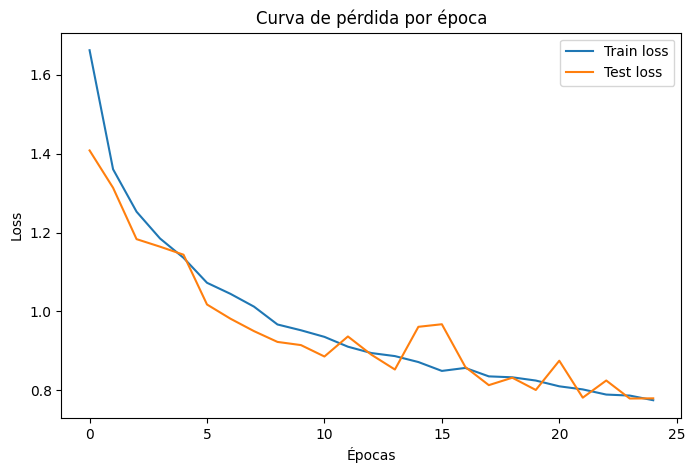

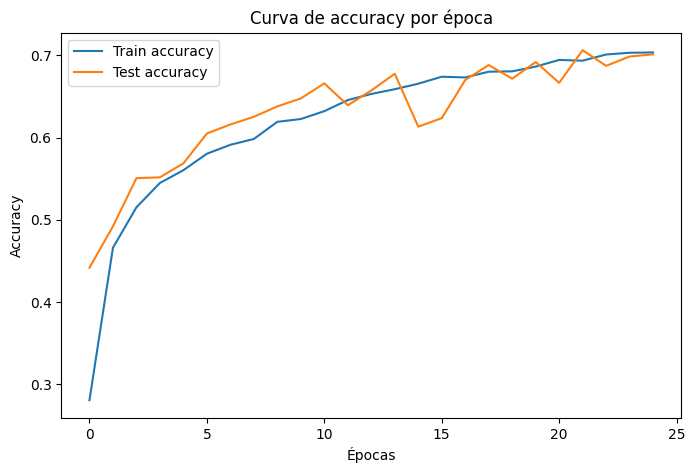

In [57]:
# Curva Pérdida
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Train loss')
plt.plot(history_cnn.history['val_loss'], label='Test loss')
plt.title('Curva de pérdida por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Curva Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Train accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Test accuracy')
plt.title('Curva de accuracy por época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Comentario
Las curvas de pérdida y accuracy muestran un comportamiento estable durante el entrenamiento. La pérdida disminuye progresivamente tanto en el conjunto de entrenamiento como en el conjunto de test, mientras que la accuracy aumenta de forma consistente hasta estabilizarse cerca del 70%.

La cercanía entre las curvas de entrenamiento y test indica que el modelo logra generalizar adecuadamente y no presenta un sobreajuste significativo.



---



4. Implementa una red neuronal Convolucional que mejore la capacidad de
generalización alcanzada en el modelo anterior. Para esto usa 16 o más capas (entre
convolucionales y densas) y mide su rendimiento.


Luego, con el modelo entrenado, aplícalo sobre el conjunto de predicción, mide su
rendimiento y compáralo con el rendimiento calculado en el modelo anterior. ¿Para
qué etiqueta el modelo se equivoca más? Muestra en forma aleatoria ocho imágenes
con la etiqueta de predicción otorgada por el modelo.


In [58]:
# Normalización
X_train_deep = X_train.astype("float32") / 255.0
X_test_deep = X_test.astype("float32") / 255.0
X_pred_deep = X_pred.astype("float32") / 255.0

In [59]:
# Modelo profundo
model_deep = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=X_train_deep.shape[1:]),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Bloque 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Bloque 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Bloque 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Bloque 5
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

model_deep.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,944,614 (15.05 MB)

 Trainable params: 3,944,614 (15.05 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history_deep = model_deep.fit(
    X_train_deep,
    y_train_ohe,
    epochs=25,
    batch_size=64,
    validation_data=(X_test_deep, y_test_ohe),
    verbose=1
)

Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.1747 - loss: 1.7915 - val_accuracy: 0.1750 - val_loss: 1.7911
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.1784 - loss: 1.7911 - val_accuracy: 0.1750 - val_loss: 1.7903
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.1786 - loss: 1.7910 - val_accuracy: 0.1750 - val_loss: 1.7903
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.1788 - loss: 1.7910 - val_accuracy: 0.1750 - val_loss: 1.7902
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.1786 - loss: 1.7910 - val_accuracy: 0.1750 - val_loss: 1.7901
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.1791 - loss: 1.7910 - val_accuracy: 0.1750 - val_loss: 1.7901
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.1778 - loss: 1.7909 - val_accuracy: 0.1750 - val_loss: 1.7901
Epoch 8/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.1792 - loss: 1.7909 - val_accu

In [61]:
# Evaluacion en test y comparacion con el modelo anterior
loss_deep, acc_deep = model_deep.evaluate(X_test_deep, y_test_ohe, verbose=0)

print(f"\nModelo punto 3 - Loss en test: {loss_cnn:.4f}")
print(f"Modelo punto 3 - Accuracy en test: {acc_cnn:.4f}")

print(f"\nModelo profundo punto 4 - Loss en test: {loss_deep:.4f}")
print(f"Modelo profundo punto 4 - Accuracy en test: {acc_deep:.4f}")

if acc_deep > acc_cnn:
    print("\nEl modelo profundo mejora la generalización respecto al modelo del punto 3.")
elif acc_deep < acc_cnn:
    print("\nEl modelo profundo NO mejora la generalización respecto al modelo del punto 3.")
else:
    print("\nAmbos modelos obtienen el mismo rendimiento en test.")


Modelo punto 3 - Loss en test: 0.7800
Modelo punto 3 - Accuracy en test: 0.7013

Modelo profundo punto 4 - Loss en test: 1.0000
Modelo profundo punto 4 - Accuracy en test: 0.6303

El modelo profundo NO mejora la generalización respecto al modelo del punto 3.


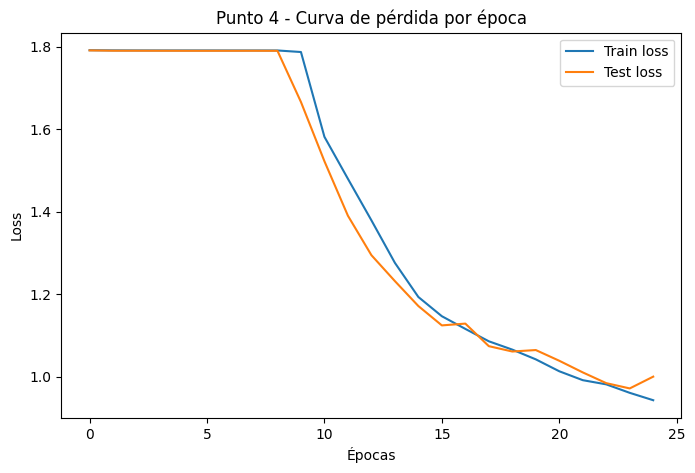

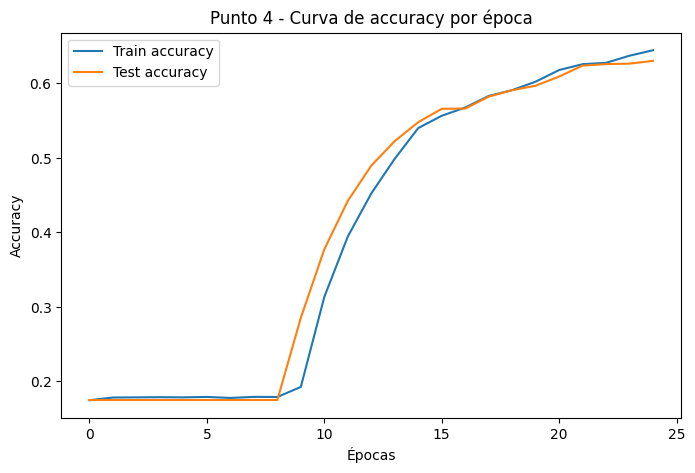

In [62]:
# Curva de pérdida
plt.figure(figsize=(8,5))
plt.plot(history_deep.history['loss'], label='Train loss')
plt.plot(history_deep.history['val_loss'], label='Test loss')
plt.title('Punto 4 - Curva de pérdida por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Curva de accuracy
plt.figure(figsize=(8,5))
plt.plot(history_deep.history['accuracy'], label='Train accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Test accuracy')
plt.title('Punto 4 - Curva de accuracy por época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [63]:
# Predicciones en test
y_prob_deep = model_deep.predict(X_test_deep)
y_pred_deep = np.argmax(y_prob_deep, axis=1)
y_true_deep = np.argmax(y_test_ohe, axis=1)

# Nombres reales de clases
nombres_clases = encoder.categories_[0]

# Matriz de confusión
cm = confusion_matrix(y_true_deep, y_pred_deep)
print("Matriz de confusión:")
print(cm)

# Errores por clase = total fila - diagonal
errores_por_clase = cm.sum(axis=1) - np.diag(cm)

for i, errores in enumerate(errores_por_clase):
    print(f"{nombres_clases[i]}: {errores} errores")

indice_peor_clase = np.argmax(errores_por_clase)
peor_clase = nombres_clases[indice_peor_clase]

print(f"\nLa etiqueta para la que el modelo se equivoca más es: {peor_clase}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step
Matriz de confusión:
[[230  60  17  14  16 100]
 [ 10 419   1   2   1  41]
 [ 52   8 344  24 101  24]
 [ 51  10  58 268 127  11]
 [ 47  36 110  36 256  25]
 [ 27  73  13   7   7 374]]
buildings: 207 errores
forest: 55 errores
glacier: 209 errores
mountain: 257 errores
sea: 254 errores
street: 127 errores

La etiqueta para la que el modelo se equivoca más es: mountain


In [64]:
print("\nClassification report:")
print(classification_report(y_true_deep, y_pred_deep, target_names=[str(x) for x in nombres_clases]))


Classification report:
              precision    recall  f1-score   support

   buildings       0.55      0.53      0.54       437
      forest       0.69      0.88      0.78       474
     glacier       0.63      0.62      0.63       553
    mountain       0.76      0.51      0.61       525
         sea       0.50      0.50      0.50       510
      street       0.65      0.75      0.70       501

    accuracy                           0.63      3000
   macro avg       0.63      0.63      0.63      3000
weighted avg       0.63      0.63      0.63      3000



In [65]:
# Predicción sobre el conjunto sin etiquetas
y_pred_predset_prob = model_deep.predict(X_pred_deep)
y_pred_predset = np.argmax(y_pred_predset_prob, axis=1)

# Convertir índices a nombres de clase
etiquetas_predichas = [nombres_clases[i] for i in y_pred_predset]

229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step


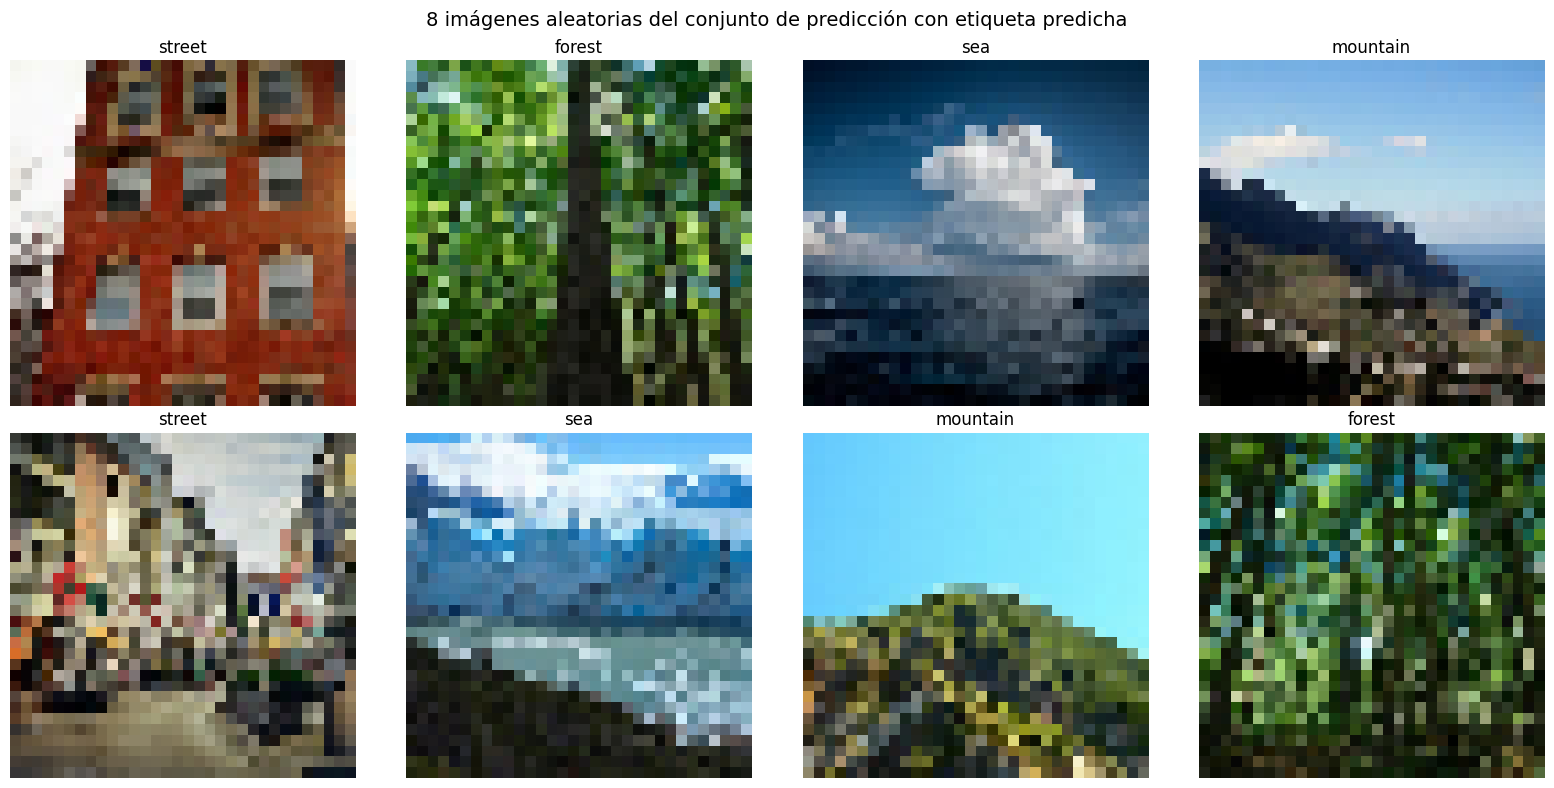

In [66]:
# Imagenes aleatorias
np.random.seed(42)
indices_pred = np.random.choice(len(X_pred_deep), size=8, replace=False)

plt.figure(figsize=(16,8))

for i, idx in enumerate(indices_pred):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_pred[idx])  # aquí puedes mostrar la imagen original
    plt.title(etiquetas_predichas[idx])
    plt.axis("off")

plt.suptitle("8 imágenes aleatorias del conjunto de predicción con etiqueta predicha", fontsize=14)
plt.tight_layout()
plt.show()

### Comentario

Se implementó una red neuronal convolucional más profunda, con 16 capas entre convolucionales y densas, con el objetivo de mejorar la capacidad de generalización respecto al modelo del punto 3. El rendimiento de ambos modelos fue evaluado utilizando el conjunto de test, ya que este dispone de etiquetas reales.

Los resultados muestran que el modelo profundo alcanzó aproximadamente un 63% de accuracy en test, mientras que el modelo del punto 3 obtuvo cerca de un 70%. Por lo tanto, el modelo más profundo no logra mejorar la capacidad de generalización del modelo anterior.

Posteriormente, se analizaron las predicciones sobre el conjunto de test mediante la matriz de confusión para identificar la clase en la que el modelo comete más errores. Finalmente, el modelo entrenado se aplicó sobre el conjunto `cnn_pred_X`, el cual fue utilizado únicamente con fines de predicción, mostrando ocho imágenes aleatorias junto con la etiqueta asignada por la red.